# EDA - Internações SIH/SUS - São Paulo 2025

Health Sentinel - Challenge FIAP 2026

Base: internações hospitalares do SIH/SUS extraídas do TabNet por local de internação, já tratadas em Power Query. Granularidade de município por mês.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = (10, 4.5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

meses = ['Jan','Fev','Mar','Abr','Mai','Jun','Jul','Ago','Set','Out','Nov','Dez']

In [4]:
df = pd.read_csv('fato_internacao.csv')
df['data_competencia'] = pd.to_datetime(df['data_competencia'])
df.head()

,cod_municipio,municipio,uf,data_competencia,ano,mes,internacoes
0,350010,ADAMANTINA,SP,2025-01-01,2025,1,414
1,350010,ADAMANTINA,SP,2025-02-01,2025,2,403
2,350010,ADAMANTINA,SP,2025-03-01,2025,3,431
3,350010,ADAMANTINA,SP,2025-04-01,2025,4,457
4,350010,ADAMANTINA,SP,2025-05-01,2025,5,519


## Estrutura da base

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3924 entries, 0 to 3923
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   cod_municipio     3924 non-null   int64         
 1   municipio         3924 non-null   object        
 2   uf                3924 non-null   object        
 3   data_competencia  3924 non-null   datetime64[ns]
 4   ano               3924 non-null   int64         
 5   mes               3924 non-null   int64         
 6   internacoes       3924 non-null   int64         
dtypes: datetime64[ns](1), int64(4), object(2)
memory usage: 214.7+ KB


In [6]:
print('Registros:', len(df))
print('Municípios:', df['cod_municipio'].nunique())
print('Meses:', df['mes'].nunique())
print('UF:', df['uf'].unique())
print('Total de internações:', df['internacoes'].sum())

Registros: 3924
Municípios: 327
Meses: 12
UF: ['SP']
Total de internações: 2896180


In [7]:
print('Nulos:', df.isna().sum().sum())
print('Duplicados:', df.duplicated(subset=['cod_municipio','data_competencia']).sum())
print('Negativos:', (df['internacoes'] < 0).sum())
print('Zerados:', (df['internacoes'] == 0).sum())

Nulos: 0
Duplicados: 0
Negativos: 0
Zerados: 41


## Estatísticas descritivas

In [8]:
df['internacoes'].describe()

,internacoes
count,3924.000000
mean,738.068298
std,3582.774351
min,0.000000
25%,71.000000
50%,190.000000
75%,488.250000
max,65735.000000


In [9]:
print('Média:', round(df['internacoes'].mean(), 1))
print('Mediana:', df['internacoes'].median())
print('Assimetria:', round(df['internacoes'].skew(), 2))
print('Curtose:', round(df['internacoes'].kurtosis(), 2))

Média: 738.1
Mediana: 190.0
Assimetria: 15.83
Curtose: 270.23


A média fica bem acima da mediana e a assimetria é alta, o que mostra que a distribuição é puxada por poucos municípios com volume muito grande.

## Distribuição

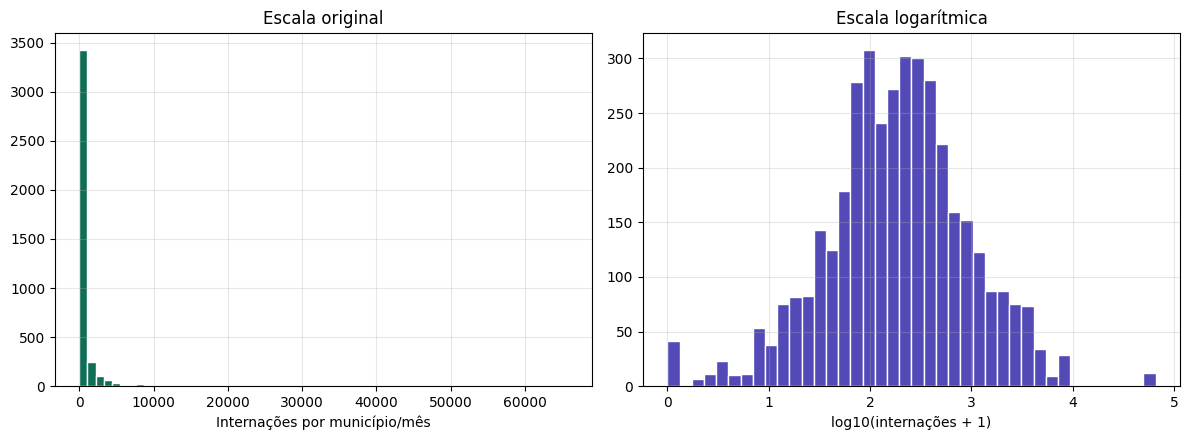

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].hist(df['internacoes'], bins=60, color='#0F6E56', edgecolor='white')
axes[0].set_title('Escala original')
axes[0].set_xlabel('Internações por município/mês')

axes[1].hist(np.log10(df['internacoes'] + 1), bins=40, color='#534AB7', edgecolor='white')
axes[1].set_title('Escala logarítmica')
axes[1].set_xlabel('log10(internações + 1)')

plt.tight_layout()
plt.show()

## Outliers

In [11]:
q1 = df['internacoes'].quantile(0.25)
q3 = df['internacoes'].quantile(0.75)
iqr = q3 - q1
limite = q3 + 1.5 * iqr

outliers = df[df['internacoes'] > limite]

print('Q1:', q1, '| Q3:', q3, '| IQR:', iqr)
print('Limite superior:', limite)
print('Outliers:', len(outliers), 'de', len(df))
print('Municípios envolvidos:', outliers['municipio'].nunique())

Q1: 71.0 | Q3: 488.25 | IQR: 417.25
Limite superior: 1114.125
Outliers: 488 de 3924
Municípios envolvidos: 45


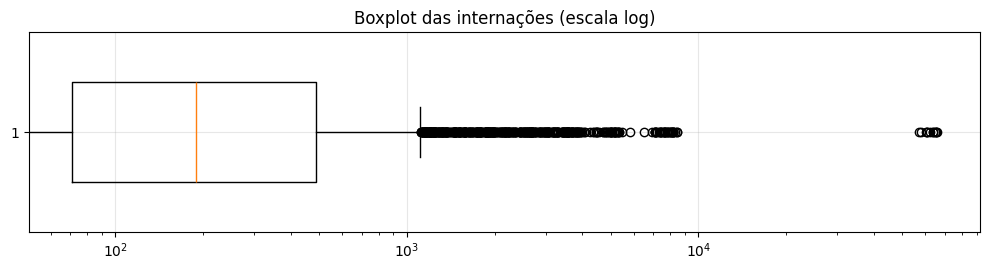

In [12]:
plt.figure(figsize=(10, 2.8))
plt.boxplot(df['internacoes'], vert=False, widths=0.5)
plt.xscale('log')
plt.title('Boxplot das internações (escala log)')
plt.tight_layout()
plt.show()

In [13]:
outliers['municipio'].value_counts().head(10)

,count
municipio,
ARARAQUARA,12
BARUERI,12
BARRETOS,12
BAURU,12
BOTUCATU,12
CATANDUVA,12
BRAGANCA PAULISTA,12
CAMPINAS,12
CARAGUATATUBA,12


Os mesmos municípios aparecem nos 12 meses. Não são erro de dado, são os polos regionais que recebem pacientes das cidades vizinhas.

## Sazonalidade

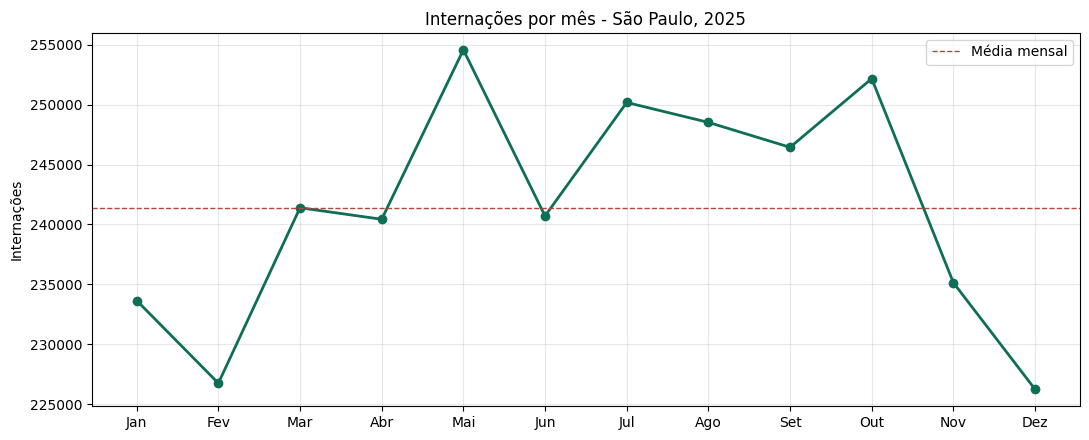

Pico: Mai 254580
Mínimo: Dez 226234
Amplitude: 12.5%


In [14]:
serie = df.groupby('mes')['internacoes'].sum()

plt.figure(figsize=(11, 4.5))
plt.plot(meses, serie.values, marker='o', linewidth=2, color='#0F6E56')
plt.axhline(serie.mean(), color='#B4453C', linestyle='--', linewidth=1, label='Média mensal')
plt.title('Internações por mês - São Paulo, 2025')
plt.ylabel('Internações')
plt.legend()
plt.tight_layout()
plt.show()

print('Pico:', meses[serie.idxmax()-1], serie.max())
print('Mínimo:', meses[serie.idxmin()-1], serie.min())
print('Amplitude: %.1f%%' % ((serie.max()-serie.min())/serie.min()*100))

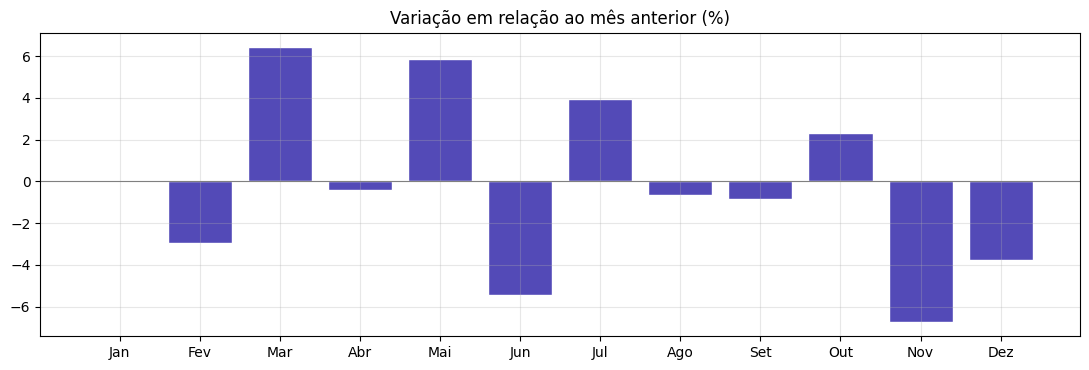

,internacoes
mes,
1,NaN
2,-3.0
3,6.5
4,-0.4
5,5.9
6,-5.4
7,3.9
8,-0.7
9,-0.8


In [15]:
variacao = serie.pct_change() * 100

plt.figure(figsize=(11, 3.8))
plt.bar(meses, variacao.fillna(0).values, color='#534AB7', edgecolor='white')
plt.axhline(0, color='gray', linewidth=0.8)
plt.title('Variação em relação ao mês anterior (%)')
plt.tight_layout()
plt.show()

variacao.round(1)

## Concentração da demanda

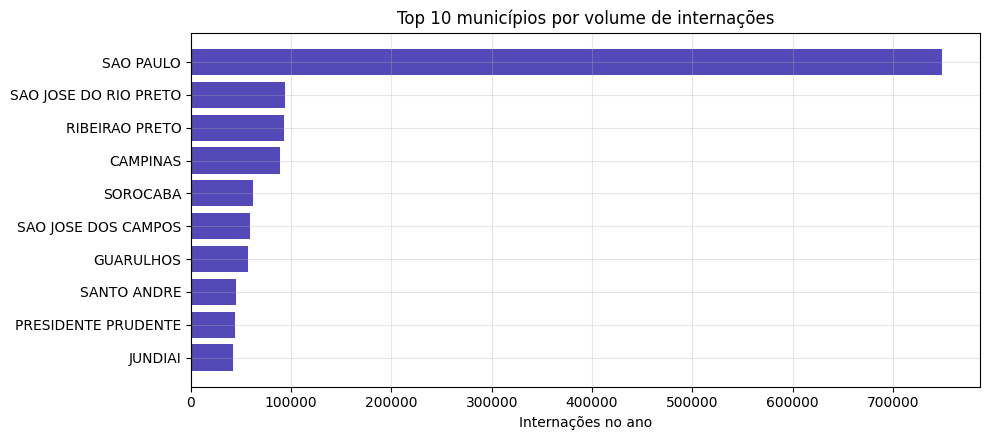

In [16]:
por_mun = df.groupby('municipio')['internacoes'].sum().sort_values(ascending=False)
top10 = por_mun.head(10)

plt.figure(figsize=(10, 4.5))
plt.barh(top10.index[::-1], top10.values[::-1], color='#534AB7')
plt.title('Top 10 municípios por volume de internações')
plt.xlabel('Internações no ano')
plt.tight_layout()
plt.show()

In [17]:
total = por_mun.sum()
acum = por_mun.cumsum() / total

n50 = (acum <= 0.50).sum() + 1
n80 = (acum <= 0.80).sum() + 1

print('Capital: %.1f%% do total' % (por_mun.iloc[0]/total*100))
print('Top 10: %.1f%% do total' % (top10.sum()/total*100))
print(n50, 'municípios concentram 50% das internações')
print(n80, 'municípios concentram 80% das internações')

Capital: 25.9% do total
Top 10: 46.1% do total
13 municípios concentram 50% das internações
64 municípios concentram 80% das internações


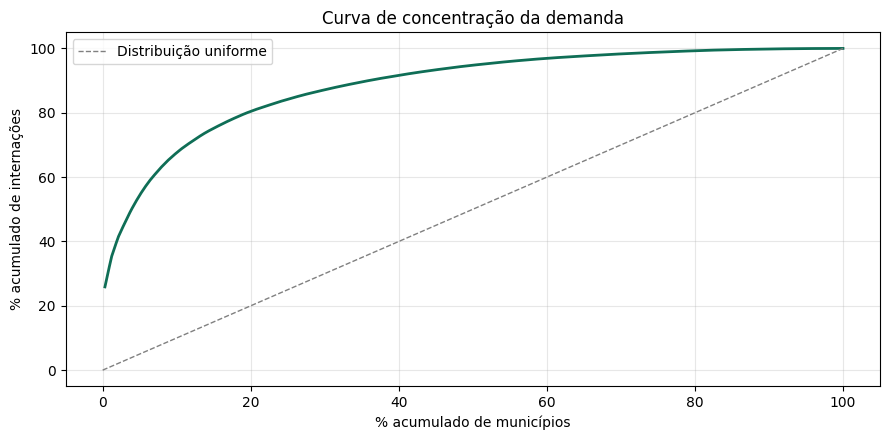

In [18]:
x = np.arange(1, len(por_mun)+1) / len(por_mun) * 100

plt.figure(figsize=(9, 4.5))
plt.plot(x, acum.values*100, linewidth=2, color='#0F6E56')
plt.plot([0,100], [0,100], '--', linewidth=1, color='gray', label='Distribuição uniforme')
plt.title('Curva de concentração da demanda')
plt.xlabel('% acumulado de municípios')
plt.ylabel('% acumulado de internações')
plt.legend()
plt.tight_layout()
plt.show()

## Estabilidade da demanda

Coeficiente de variação = desvio padrão dividido pela média de cada município. Mede o quanto a demanda oscila ao longo do ano.

In [19]:
estab = df.groupby('municipio')['internacoes'].agg(['mean','std','sum'])
estab['cv'] = estab['std'] / estab['mean']

relevantes = estab[estab['sum'] >= 500]

print('Mais instáveis:')
print(relevantes.nlargest(8, 'cv')[['sum','cv']].round(2))
print()
print('Mais estáveis:')
print(relevantes.nsmallest(8, 'cv')[['sum','cv']].round(2))

Mais instáveis:
                     sum    cv
municipio                     
CABREUVA             805  0.91
MIRASSOL            1838  0.55
CERQUILHO            868  0.55
PORTO FELIZ         4057  0.49
CACAPAVA            3253  0.48
REGENTE FEIJO       1124  0.40
URUPES               877  0.38
SAO MIGUEL ARCANJO  1285  0.36

Mais estáveis:
                          sum    cv
municipio                          
VOTUPORANGA             12089  0.03
SUMARE                  13140  0.04
BARRETOS                32655  0.05
SAO PAULO              749495  0.05
FRANCA                  24608  0.05
JAU                     27331  0.05
SAO JOSE DO RIO PRETO   94206  0.05
PRESIDENTE PRUDENTE     43566  0.05


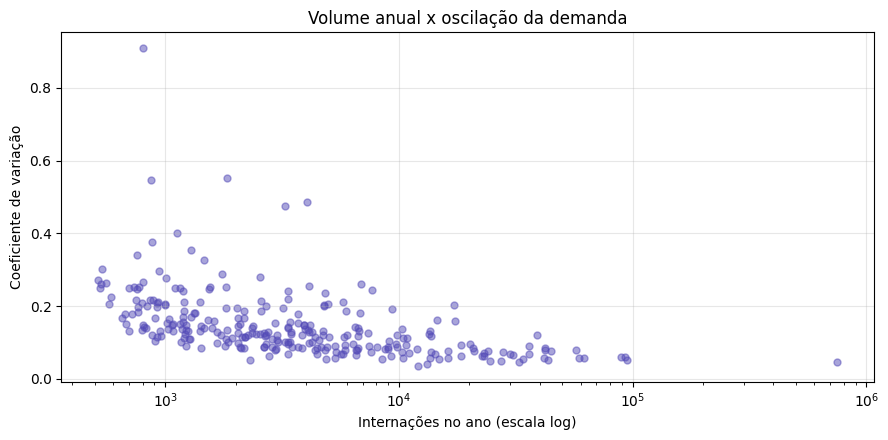

In [20]:
plt.figure(figsize=(9, 4.5))
plt.scatter(relevantes['sum'], relevantes['cv'], alpha=0.5, color='#534AB7', s=25)
plt.xscale('log')
plt.title('Volume anual x oscilação da demanda')
plt.xlabel('Internações no ano (escala log)')
plt.ylabel('Coeficiente de variação')
plt.tight_layout()
plt.show()

## Conclusões

A base está íntegra: sem nulos, sem duplicidade na chave município/mês e com os 12 meses completos para todos os municípios.

A distribuição das internações é bastante desigual. A maior parte dos municípios tem volume baixo e alguns poucos concentram a demanda do estado. Por isso o volume absoluto não serve para comparar municípios entre si.

Os outliers não são erro de dado. São os mesmos municípios em todos os meses, que funcionam como referência regional.

Existe sazonalidade, com mais internações no meio do ano e queda em dezembro.

Essa concentração é o motivo de o dashboard usar internações por 10 mil habitantes em vez do número absoluto.